<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana8/teste2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.5 MB/s eta 0:00:00


EXEMPLO 2: PIPELINE COM DIRETÓRIO PRÓPRIO E AUTO-LABELING PURAMENTE LOCAL
[ESTRUTURA CRIADA]
-> Faça o upload das suas fotos de treino em: /content/dataset_proprio/images/train
-> Faça o upload da sua imagem de teste em: /content/dataset_proprio/images/test

[AUTO-LABELING] Varrendo suas fotos de treino locais para gerar os arquivos .txt...
   -> Processando: Captura de tela 2026-09-22 200402.png
[SUCESSO] Auto-labeling concluído para 1 imagem(ns) enviada(s)!

[PREDIÇÃO EXTERNA] Executando teste em uma imagem inédita...
-> Utilizando a imagem de teste: Captura de tela 2026-09-22 200402.png

image 1/1 /content/dataset_proprio/images/test/Captura de tela 2026-09-22 200402.png: 640x608 4 persons, 2 skateboards, 4907.1ms
Speed: 6.6ms preprocess, 4907.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 608)
[LAUDO DA AVALIAÇÃO] Detectados 6 objeto(s) na nova foto.
   -> Alvo 1 validado com 96.9% de certeza.
   -> Alvo 2 validado com 90.2% de certeza.
   -> Alvo 3 validado com 88

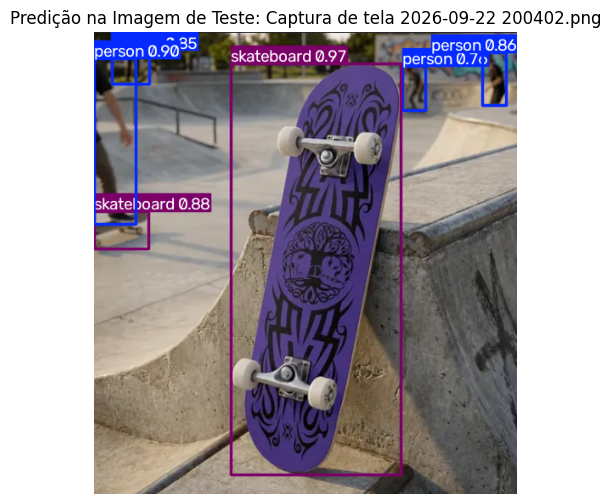

In [11]:
import cv2
import yaml
from pathlib import Path
from ultralytics import YOLO

print("="*80)
print("EXEMPLO 2: PIPELINE COM DIRETÓRIO PRÓPRIO E AUTO-LABELING PURAMENTE LOCAL")
print("="*80)

# 1. Configurando a árvore de diretórios oficial no ambiente
base_dir = Path.cwd() / "dataset_proprio"
dir_imgs_train = base_dir / "images" / "train"
dir_lbls_train = base_dir / "labels" / "train"
dir_imgs_test  = base_dir / "images" / "test"

for d in [dir_imgs_train, dir_lbls_train, dir_imgs_test]:
    d.mkdir(parents=True, exist_ok=True)

print(f"[ESTRUTURA CRIADA]")
print(f"-> Faça o upload das suas fotos de treino em: {dir_imgs_train}")
print(f"-> Faça o upload da sua imagem de teste em: {dir_imgs_test}")

# 2. Executando o Auto-Labeling nas imagens que você subiu na pasta de treino
print("\n[AUTO-LABELING] Varrendo suas fotos de treino locais para gerar os arquivos .txt...")
modelo_professor = YOLO('yolov8x.pt')

# Buscando apenas arquivos de imagem reais enviados por você
imagens_treino = list(dir_imgs_train.glob("*.jpg")) + list(dir_imgs_train.glob("*.png")) + list(dir_imgs_train.glob("*.jpeg"))

if len(imagens_treino) == 0:
    print("[ATENÇÃO] Nenhuma imagem encontrada na pasta 'dataset_proprio/images/train'.")
    print("Por favor, faça o upload das suas imagens de treino antes de executar esta célula.")
else:
    for img_path in imagens_treino:
        print(f"   -> Processando: {img_path.name}")
        # A IA professora prediz os objetos na sua foto
        preds = modelo_professor.predict(source=str(img_path), conf=0.50, verbose=False)

        # Cria o arquivo .txt espelho na pasta de labels correspondente
        txt_path = dir_lbls_train / f"{img_path.stem}.txt"

        with open(txt_path, 'w') as f:
            for box in preds[0].boxes:
                cls_id = int(box.cls[0].item())
                # Extrai as coordenadas normalizadas (0.0 a 1.0) exigidas pelo YOLO
                x_c, y_c, w, h = box.xywhn[0].tolist()
                f.write(f"{cls_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}\n")

    print(f"[SUCESSO] Auto-labeling concluído para {len(imagens_treino)} imagem(ns) enviada(s)!")

# 3. Gerando o arquivo de configuração YAML apontando para o seu diretório
yaml_config = {
    'path': str(base_dir.absolute()),
    'train': 'images/train',
    'val': 'images/train',
    'nc': 1,
    'names': modelo_professor.names
}
yaml_file = base_dir / "config_proprio.yaml"
with open(yaml_file, 'w') as yf:
    yaml.dump(yaml_config, yf, sort_keys=False)

# 4. PREDIÇÃO EM UMA IMAGEM DE TESTE SEPARADA (Enviada por você)
print("\n[PREDIÇÃO EXTERNA] Executando teste em uma imagem inédita...")
imagens_teste = list(dir_imgs_test.glob("*.jpg")) + list(dir_imgs_test.glob("*.png")) + list(dir_imgs_test.glob("*.jpeg"))

if len(imagens_teste) == 0:
    print("[ATENÇÃO] Nenhuma imagem de teste encontrada na pasta 'dataset_proprio/images/test'.")
    print("Faça o upload de uma imagem separada para testar o modelo.")
else:
    caminho_teste = imagens_teste[0]
    print(f"-> Utilizando a imagem de teste: {caminho_teste.name}")

    # Carregando o avaliador e rodando a predição
    modelo_avaliador = YOLO('yolov8x.pt')
    resultado_externo = modelo_avaliador.predict(source=str(caminho_teste), conf=0.50)[0]

    print(f"[LAUDO DA AVALIAÇÃO] Detectados {len(resultado_externo.boxes)} objeto(s) na nova foto.")
    for idx, b in enumerate(resultado_externo.boxes):
        conf_val = b.conf[0].item()
        print(f"   -> Alvo {idx+1} validado com {conf_val*100:.1f}% de certeza.")

    # Exibindo o resultado visual da predição externa
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(resultado_externo.plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"Predição na Imagem de Teste: {caminho_teste.name}")
    plt.axis('off')
    plt.show()